# Cell Composition Visualization

将 Stage 2 输出的 cell 组成数据加载到 ST h5ad 中，并在切片上可视化

1. Loading Data...
ST data shape: (524, 1000)
CSV data shape: (524, 25)

2. Fixing Indices...
ST Index Head:  ['0', '1', '2']
CSV Index Head: ['0', '1', '2']
初次尝试共享 spots: 524

3. Merging Data (Shared: 524)...
-> Cell composition added to adata.obs

4. Computing Dominant Cell Types...
Top 5 Dominant Types:
dominant_cell_type
L5/L6         317
L2/L3/L4      120
Cluster_37     22
Cluster_45     16
Cluster_51     12
Name: count, dtype: int64

5. Plotting and Saving...
已删除损坏的 adata.uns['spatial']，将使用纯坐标模式绘图。


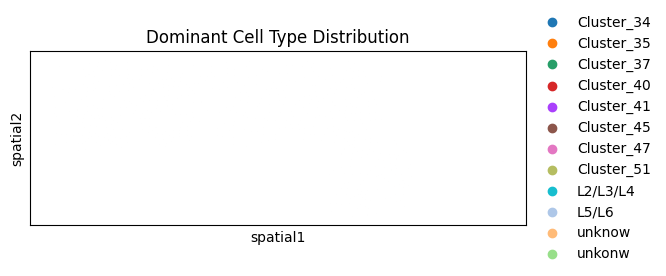

In [26]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# --- 参数配置 ---
cell_composition_csv = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/DATA4/Dataset4_cell_composition.csv"
st_h5ad_path = "/mnt/d/ST_Graduation_Project_data/DATA4/Dataset4_ST.h5ad"
output_dir = Path("/mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/DATA4/")
output_h5ad = output_dir / "DATA4_ST_with_cell_composition.h5ad"

# --- 1. 加载数据 ---
print("1. Loading Data...")
adata = sc.read_h5ad(st_h5ad_path)
# 注意：index_col=0 假设第一列是 Barcode。如果不是，请改为 None 并手动指定 column
cell_composition = pd.read_csv(cell_composition_csv, index_col=0)

print(f"ST data shape: {adata.shape}")
print(f"CSV data shape: {cell_composition.shape}")

# --- 2. 核心修复：索引对齐与清洗 ---
print("\n2. Fixing Indices...")

# 强制转换为字符串并去除首尾空格 (解决 int vs str 问题)
adata.obs_names = adata.obs_names.astype(str).str.strip()
cell_composition.index = cell_composition.index.astype(str).str.strip()

# 打印前几个看看长啥样（调试用）
print(f"ST Index Head:  {adata.obs_names[:3].tolist()}")
print(f"CSV Index Head: {cell_composition.index[:3].tolist()}")

# 计算交集
shared_spots = adata.obs_names.intersection(cell_composition.index)
print(f"初次尝试共享 spots: {len(shared_spots)}")

# --- 2.1 备用方案：处理常见的 -1 后缀不一致问题 ---
if len(shared_spots) == 0:
    print("⚠️ 警告：交集为 0，尝试去除 '-1' 后缀匹配...")
    # 尝试方案 A: adata 有 -1，CSV 没有
    adata_clean = adata.obs_names.str.replace(r'-\d+$', '', regex=True)
    # 尝试方案 B: CSV 有 -1，adata 没有
    csv_clean = cell_composition.index.str.replace(r'-\d+$', '', regex=True)
    
    # 检查 A
    if len(adata_clean.intersection(cell_composition.index)) > 0:
        print("-> 检测到 ST 数据包含后缀，已修正匹配。")
        adata.obs_names = adata_clean
        shared_spots = adata.obs_names.intersection(cell_composition.index)
    # 检查 B
    elif len(adata.obs_names.intersection(csv_clean)) > 0:
        print("-> 检测到 CSV 数据包含后缀，已修正匹配。")
        cell_composition.index = csv_clean
        shared_spots = adata.obs_names.intersection(cell_composition.index)
    else:
        # 如果还是 0，抛出详细错误以便调试
        raise ValueError(f"无法对齐！\nST 示例: {adata.obs_names[:3].tolist()}\nCSV 示例: {cell_composition.index[:3].tolist()}")

# --- 3. 数据合并 (由慢循环改为高效合并) ---
print(f"\n3. Merging Data (Shared: {len(shared_spots)})...")

# 只保留共享的 spots
adata_subset = adata[shared_spots].copy()
cell_composition_aligned = cell_composition.loc[shared_spots]

# 直接合并：Pandas 会自动根据索引对齐，不需要写循环
# 给列名加上前缀，防止和现有列名冲突
cell_composition_aligned.columns = [f"cell_comp_{c}" for c in cell_composition_aligned.columns]
adata_subset.obs = pd.concat([adata_subset.obs, cell_composition_aligned], axis=1)

print("-> Cell composition added to adata.obs")

# --- 4. 计算 Dominant Cell Type ---
print("\n4. Computing Dominant Cell Types...")

# 提取刚刚加进去的列
comp_cols = [c for c in adata_subset.obs.columns if c.startswith('cell_comp_')]
comp_df = adata_subset.obs[comp_cols]

# 矢量化计算最大值，速度快
# idxmax 返回列名，我们用 str.replace 去掉前缀
adata_subset.obs['dominant_cell_type'] = comp_df.idxmax(axis=1).str.replace('cell_comp_', '')
adata_subset.obs['dominant_cell_value'] = comp_df.max(axis=1)

print("Top 5 Dominant Types:")
print(adata_subset.obs['dominant_cell_type'].value_counts().head())

# --- 5. 绘图与保存 ---
print("\n5. Plotting and Saving...")

# 确保 output 目录存在
output_dir.mkdir(parents=True, exist_ok=True)
# 1. 强制删除损坏的 spatial 元数据
if 'spatial' in adata_subset.uns:
    del adata_subset.uns['spatial']
    print("已删除损坏的 adata.uns['spatial']，将使用纯坐标模式绘图。")
try:
    sc.pl.spatial(
        adata_subset,
        color='dominant_cell_type',
        spot_size=0.5, # 必须指定，因为没有 uns['spatial']
        title='Dominant Cell Type Distribution',
        show=True
    )
except Exception as e:
    print(f"绘图出错 (可能是没有空间坐标): {e}")
    # 备选：如果是没有 spatial key 的普通坐标
    if 'spatial' in adata_subset.obsm:
        print("尝试使用 embedding 模式绘图...")
        sc.pl.embedding(adata_subset, basis='spatial', color='dominant_cell_type', show=True)

In [25]:
sc.pl.spatial(
    adata_subset,
    color='dominant_cell_type',
    spot_size=0.5, # 必须指定，因为没有 uns['spatial']
    title='Dominant Cell Type Distribution',
    show=True
)

AttributeError: 'numpy.ndarray' object has no attribute 'keys'

1. Loading Data...
   ST Data Shape: (189, 882)
   CSV Data Shape: (189, 15)

2. Aligning Indices...
   最终共享 Spots 数量: 189

3. Merging Data...
   即将绘制 15 种细胞类型。

4. Calculating Plotting Parameters...
   Median distance between spots: 1.00

5. Plotting (Pixelated Style)...

Saving to: /mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/STARmap/pixelated_cell_composition.png


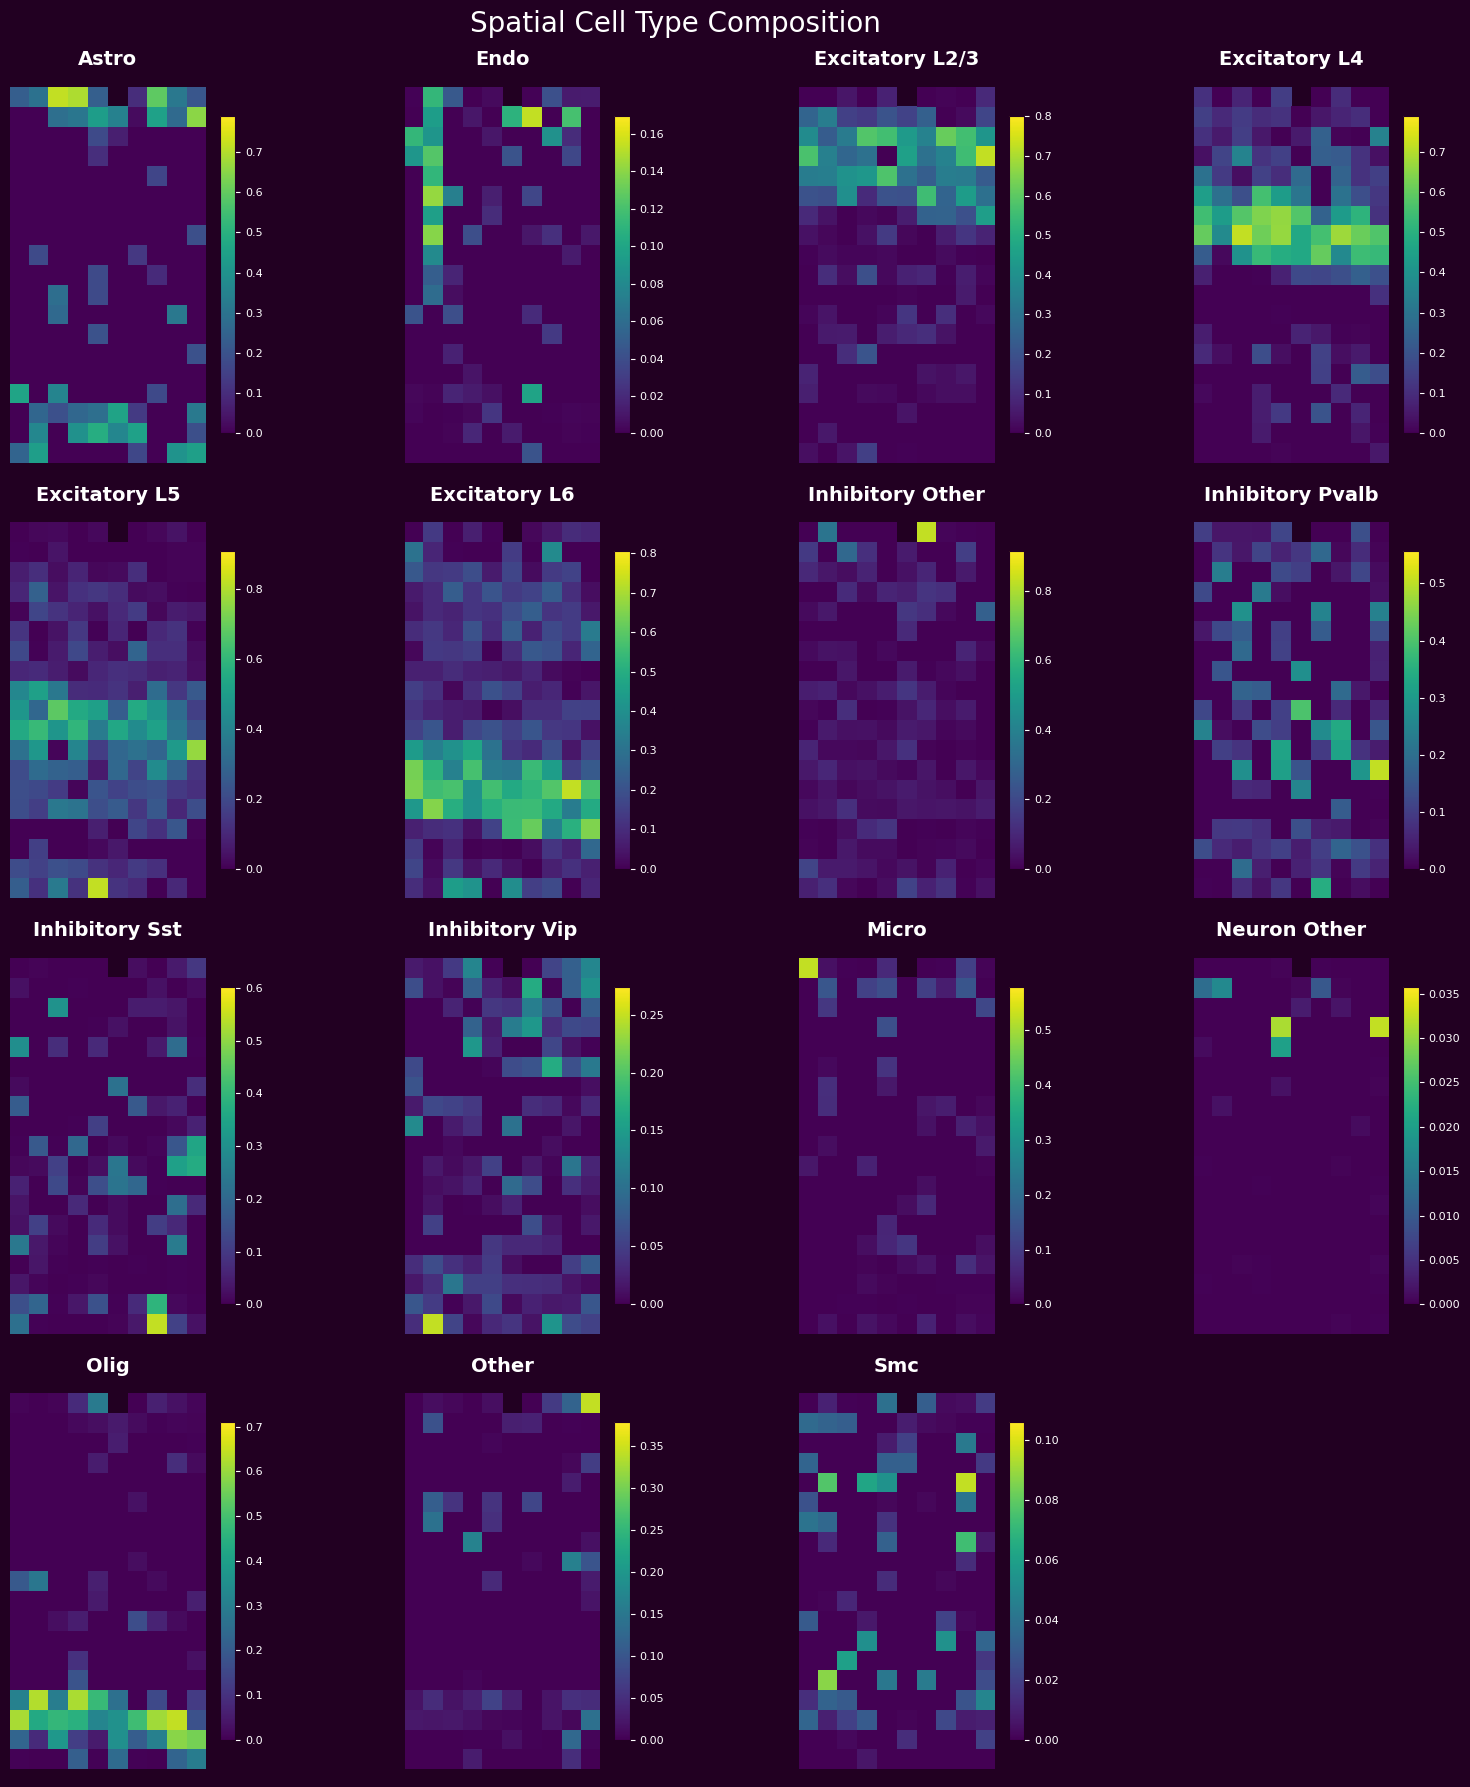


Done!


In [8]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from pathlib import Path
import warnings

# 忽略警告，保持输出干净
warnings.filterwarnings('ignore')

# ==========================================
# 1. 文件路径配置 (请修改这里)
# ==========================================
# 细胞组成 CSV 文件路径
cell_composition_csv = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/STARmap/Spatial_cell_composition.csv"

# ST h5ad 文件路径
st_h5ad_path = "/mnt/d/ST_Graduation_Project_data/STARmap/Spatial.h5ad"

# 图片保存路径
output_dir = Path("/mnt/d/ST_Graduation_Project/SC_MAP_ST/deconv_results/STARmap/")
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / 'pixelated_cell_composition.png'

# ==========================================
# 2. 数据加载与清洗
# ==========================================
print("1. Loading Data...")
adata = sc.read_h5ad(st_h5ad_path)

# 读取 CSV (假设第一列是 Spot ID)
cell_composition = pd.read_csv(cell_composition_csv, index_col=0)

print(f"   ST Data Shape: {adata.shape}")
print(f"   CSV Data Shape: {cell_composition.shape}")

# --- 核心修复：索引对齐 ---
print("\n2. Aligning Indices...")
# 强制转为字符串并去除空格
adata.obs_names = adata.obs_names.astype(str).str.strip()
cell_composition.index = cell_composition.index.astype(str).str.strip()

# 计算交集
shared_spots = adata.obs_names.intersection(cell_composition.index)

# 如果交集为0，尝试去除 "-1" 后缀再次匹配
if len(shared_spots) == 0:
    print("   ⚠️  交集为 0，尝试自动去除 '-1' 后缀...")
    adata_clean = adata.obs_names.str.replace(r'-\d+$', '', regex=True)
    csv_clean = cell_composition.index.str.replace(r'-\d+$', '', regex=True)
    
    if len(adata_clean.intersection(cell_composition.index)) > 0:
        adata.obs_names = adata_clean
        shared_spots = adata.obs_names.intersection(cell_composition.index)
        print("   -> ST数据后缀已去除，匹配成功。")
    elif len(adata.obs_names.intersection(csv_clean)) > 0:
        cell_composition.index = csv_clean
        shared_spots = adata.obs_names.intersection(cell_composition.index)
        print("   -> CSV数据后缀已去除，匹配成功。")
    else:
        raise ValueError("无法对齐 Spot ID！请检查两个文件的索引名称是否一致。")

print(f"   最终共享 Spots 数量: {len(shared_spots)}")

# ==========================================
# 3. 数据合并
# ==========================================
print("\n3. Merging Data...")
# 只保留共享部分
adata_subset = adata[shared_spots].copy()
cell_composition_aligned = cell_composition.loc[shared_spots]

# 将细胞比例数据放入 obs
cell_composition_aligned.columns = [f"cell_comp_{c}" for c in cell_composition_aligned.columns]
adata_subset.obs = pd.concat([adata_subset.obs, cell_composition_aligned], axis=1)

# 获取所有要画的细胞类型
cell_comp_cols = [col for col in adata_subset.obs.columns if col.startswith('cell_comp_')]
cell_types = [col.replace('cell_comp_', '') for col in cell_comp_cols]
print(f"   即将绘制 {len(cell_types)} 种细胞类型。")

# ==========================================
# 4. 空间坐标修复与参数计算
# ==========================================
print("\n4. Calculating Plotting Parameters...")

# 提取坐标
if 'spatial' in adata_subset.obsm:
    coords = adata_subset.obsm['spatial']
else:
    # 如果没有 spatial，尝试找前两列数值作为坐标
    print("   ⚠️  Warning: obsm['spatial'] not found. Using generic X/Y...")
    # 这里的逻辑是找不到就报错，或者你自己指定列
    raise ValueError("adata.obsm['spatial'] 不存在，无法绘图。")

# 强制修复坐标维度 (N, 1) -> (N, 2) 防止报错
if coords.ndim == 1 or coords.shape[1] == 1:
    print("   -> 修复 1D 坐标为 2D...")
    coords = coords.reshape(-1, 1) if coords.ndim==1 else coords
    coords = np.hstack([coords, np.zeros((coords.shape[0], 1))])

x_raw, y_raw = coords[:, 0], coords[:, 1]

# 计算 Spot 之间的距离，用于确定方块大小
nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
dists, _ = nbrs.kneighbors(coords)
median_dist = np.median(dists[:, 1])

# 如果 median_dist 为 0 (比如坐标重叠)，给一个默认值
if median_dist == 0:
    median_dist = 1.0

print(f"   Median distance between spots: {median_dist:.2f}")

# ==========================================
# 5. 绘图 (像素风)
# ==========================================
print("\n5. Plotting (Pixelated Style)...")

# 布局设置
n_types = len(cell_types)
n_cols = 4  # 每行 4 张图
n_rows = (n_types + n_cols - 1) // n_cols

# 设置画布大小 (宽, 高)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4.5), dpi=100)

# 设置深色背景 (配合 Viridis 效果更好)

bg_color = '#220022' # 深紫黑色
fig.patch.set_facecolor(bg_color)

if n_types > 1:
    axes = axes.flatten()
else:
    axes = [axes]

# 设置色盘 (Viridis: 紫->蓝->绿->黄)
cmap = plt.get_cmap('viridis')

# 关键参数：方块大小调整系数
# 如果图上的方块之间有缝隙，把这个数字改大 (如 180 -> 250)
# 如果方块重叠太严重，把这个数字改小 (如 180 -> 100)
marker_size = 210 

for idx, (col, cell_type) in enumerate(zip(cell_comp_cols, cell_types)):
    ax = axes[idx]
    
    # 获取当前细胞类型的比例值
    values = adata_subset.obs[col].values
    
    # 绘制方块散点
    scatter = ax.scatter(
        x_raw, y_raw, 
        c=values, 
        s=marker_size, 
        marker='s',        # <--- 's' 代表方块 (square)
        cmap=cmap,
        vmin=0, 
        vmax=values.max()*1.1, # 稍微调低上限，让高表达区域更亮
        alpha=1.0,         # 不透明，像像素块
        edgecolors='none', # 去掉边框，实现无缝拼接
        zorder=10
    )
    
    # 设置子图背景色 (与主背景一致或更深)
    ax.set_facecolor(bg_color)
    
    # 调整坐标轴比例
    ax.set_aspect('equal')
    
    # 移除坐标轴刻度和边框 (纯净模式)
    ax.axis('off')
    
    # 设置标题
    ax.set_title(f'{cell_type}', fontsize=14, color='white', fontweight='bold', pad=10)
    
    # 添加简单的颜色条 (Colorbar)
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white')     # 刻度线白色
    cbar.outline.set_edgecolor(bg_color)             # 边框颜色
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white', fontsize=8) # 文字白色

# 隐藏多余的空白子图
for idx in range(n_types, len(axes)):
    axes[idx].axis('off')

# 添加总标题
plt.suptitle('Spatial Cell Type Composition', fontsize=20, color='white', y=0.99)
plt.tight_layout()

# ==========================================
# 6. 保存与显示
# ==========================================
print(f"\nSaving to: {output_file}")
# savefig 时也要指定 facecolor，否则背景可能是白色的
fig.savefig(output_file, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

plt.show()
print("\nDone!")

绘制 Spot Cosine Similarity 热图
Loading cosine similarity from: /mnt/d/ST_Graduation_Project/SC_MAP_ST/stage2_results/PDAC/PDAC_spot_cosine_similarity.csv
Cosine similarity shape: (428, 2)

First 5 rows:
  spot_id  cosine_similarity
0   10x10           0.599851
1   10x13           0.490192
2   10x14           0.449945
3   10x15           0.397413
4   10x16           0.390640

坐标范围:
X: 2 - 30
Y: 8 - 34
Cosine similarity: 0.1637 - 0.7114

Pivot table shape: (26, 29)
Missing values: 326


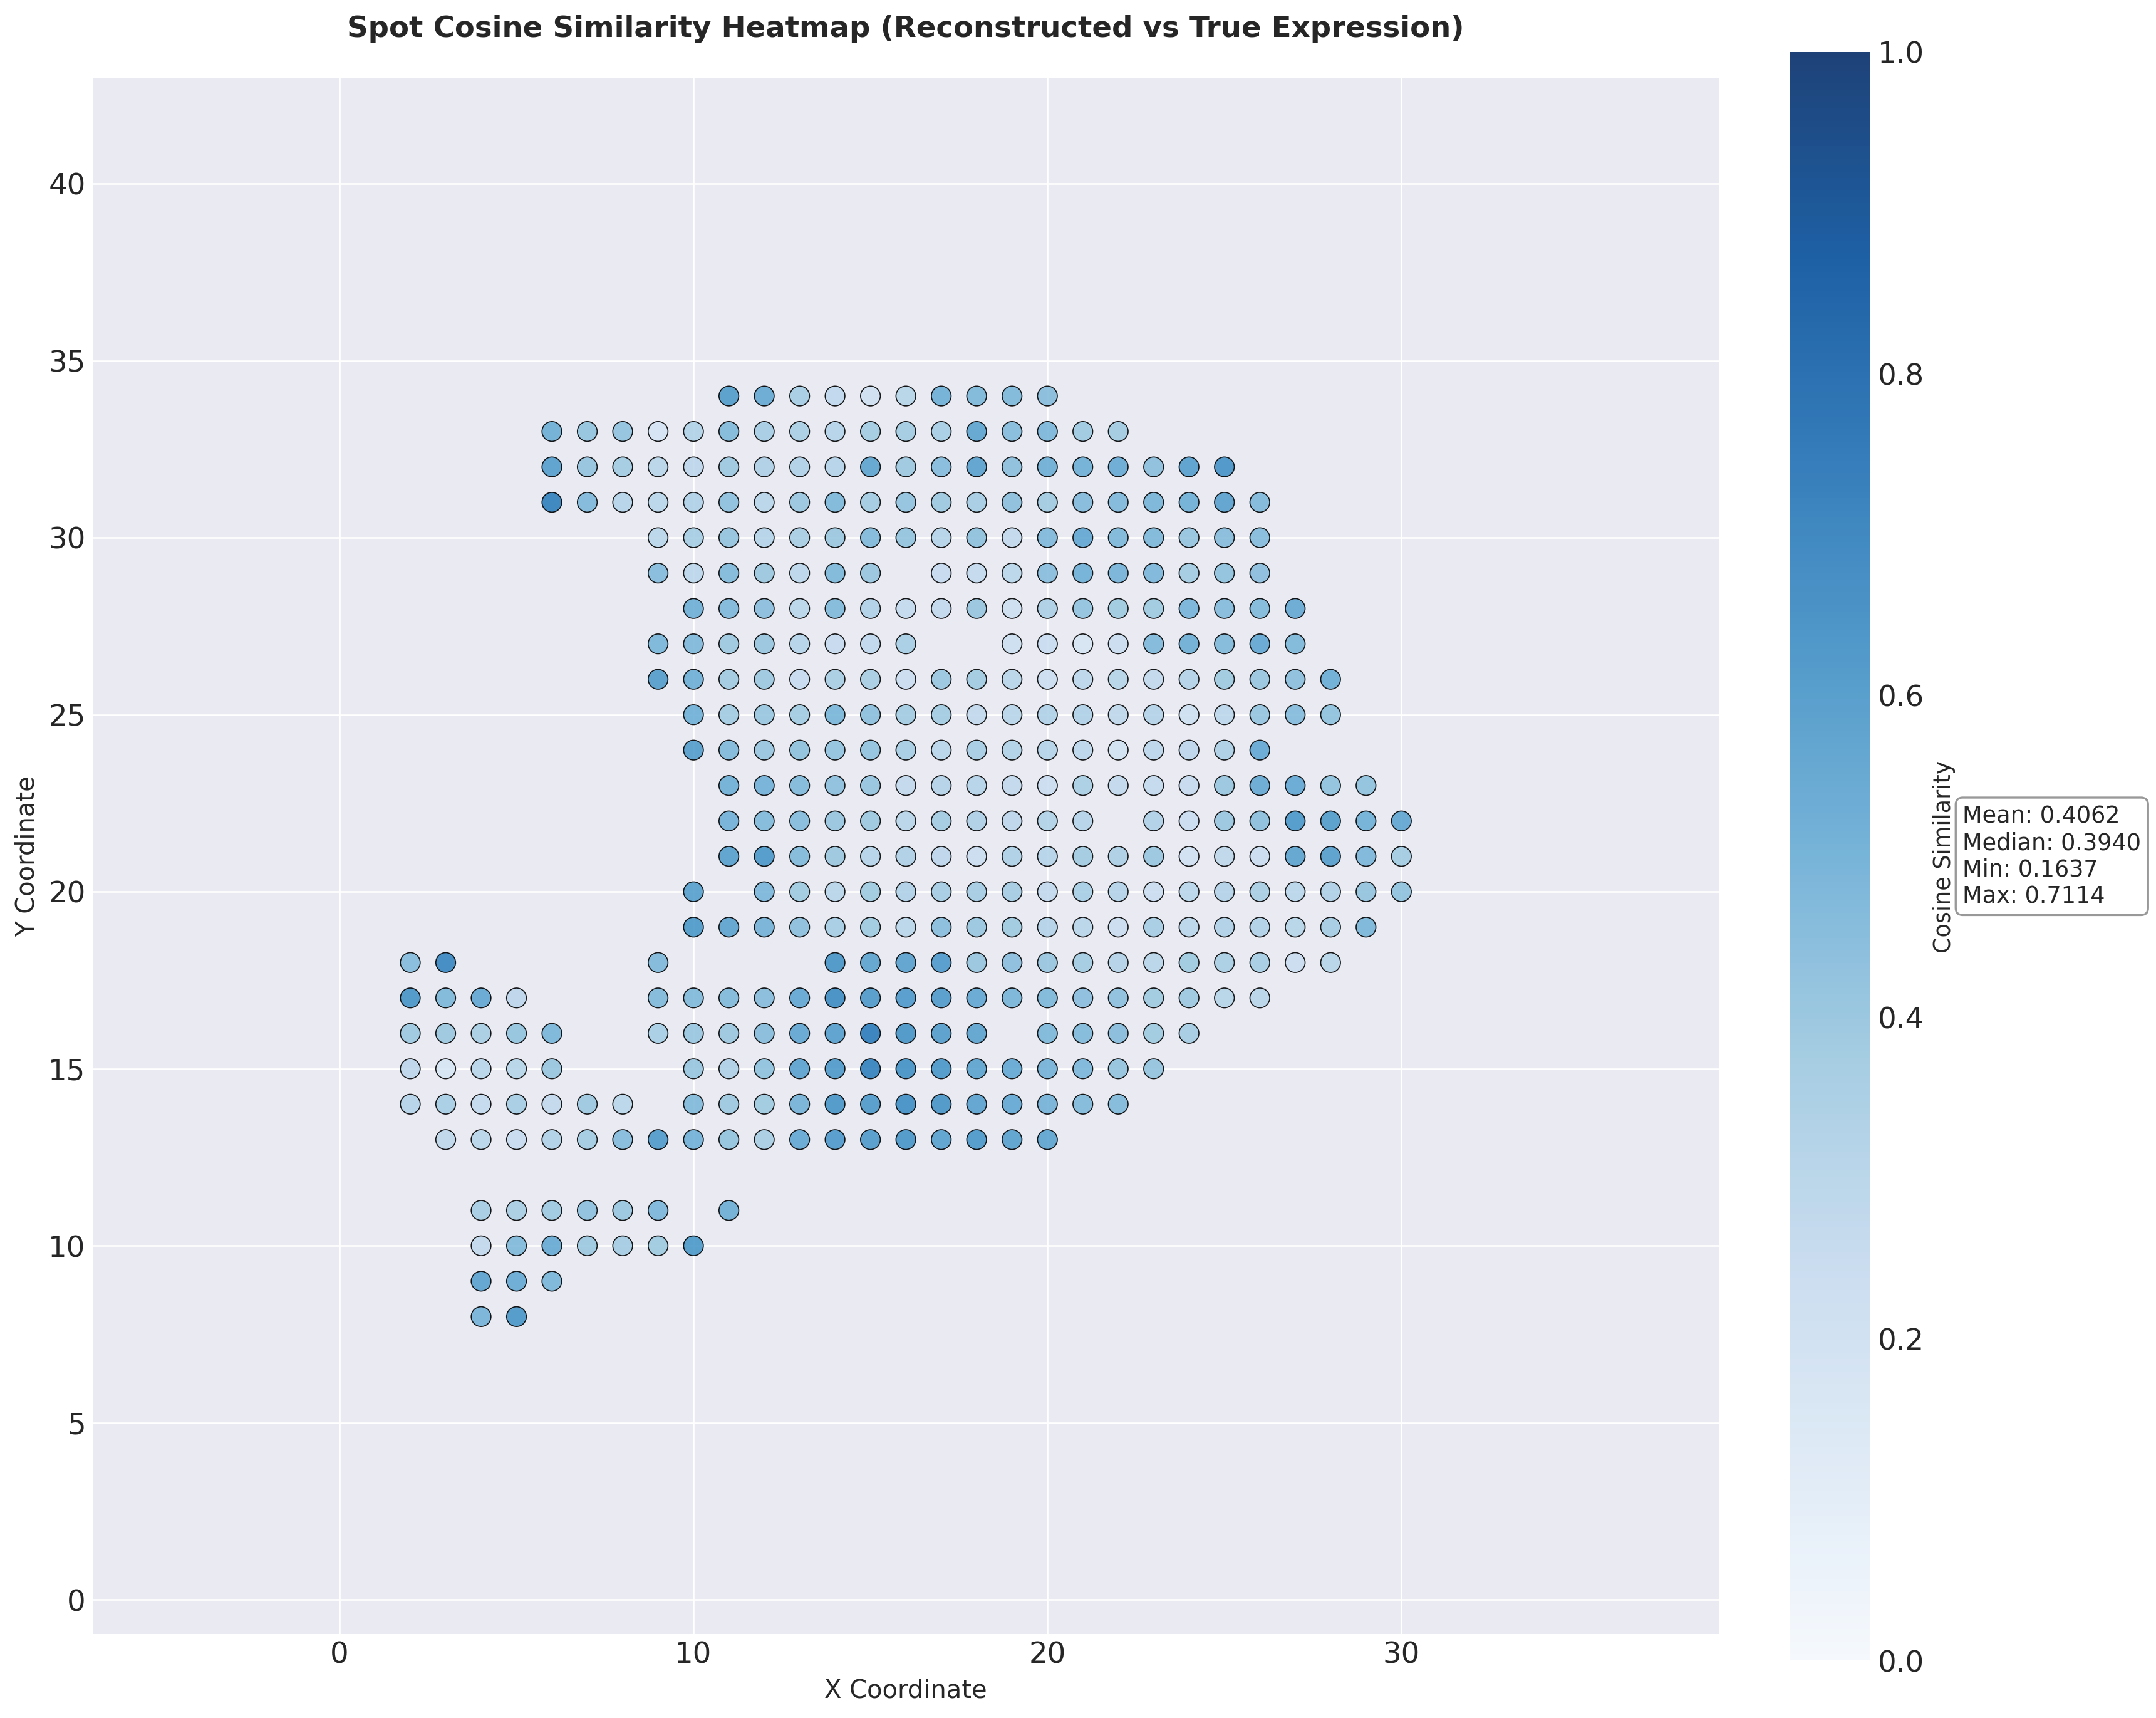

In [4]:
# 绘制 Cosine Similarity 热图
print("="*70)
print("绘制 Spot Cosine Similarity 热图")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 加载 cosine similarity CSV
cosine_csv = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/stage2_results/PDAC/PDAC_spot_cosine_similarity.csv"
print(f"Loading cosine similarity from: {cosine_csv}")

cos_df = pd.read_csv(cosine_csv)
print(f"Cosine similarity shape: {cos_df.shape}")
print(f"\nFirst 5 rows:")
print(cos_df.head())

# 解析 spot_id 获取 x, y 坐标
# spot_id 格式: "XxY" (例如 "10x10")
cos_df['x_coord'] = cos_df['spot_id'].str.split('x').str[0].astype(int)
cos_df['y_coord'] = cos_df['spot_id'].str.split('x').str[1].astype(int)

print(f"\n坐标范围:")
print(f"X: {cos_df['x_coord'].min()} - {cos_df['x_coord'].max()}")
print(f"Y: {cos_df['y_coord'].min()} - {cos_df['y_coord'].max()}")
print(f"Cosine similarity: {cos_df['cosine_similarity'].min():.4f} - {cos_df['cosine_similarity'].max():.4f}")

# 创建透视表 (pivot table) 用于热图
# 行=Y坐标, 列=X坐标, 值=cosine_similarity
pivot_data = cos_df.pivot(index='y_coord', columns='x_coord', values='cosine_similarity')

print(f"\nPivot table shape: {pivot_data.shape}")
print(f"Missing values: {pivot_data.isna().sum().sum()}")

# 创建热图 - 使用圆形散点图
fig, ax = plt.subplots(figsize=(14, 12), dpi=120)

# 获取 x, y 坐标和相似度值
x_coords = cos_df['x_coord'].values
y_coords = cos_df['y_coord'].values
similarity_values = cos_df['cosine_similarity'].values

# 计算spot大小（基于坐标密度）
x_range = x_coords.max() - x_coords.min()
y_range = y_coords.max() - y_coords.min()
spot_size = min(x_range, y_range) / max(len(np.unique(x_coords)), len(np.unique(y_coords))) * 100

# 使用scatter绘制圆形spot
scatter = ax.scatter(
    x_coords, 
    y_coords, 
    c=similarity_values,
    s=spot_size**1,  # 点的大小
    cmap='Blues',
    vmin=0,
    vmax=1,
    alpha=0.9,
    edgecolors='black',
    linewidths=0.5
)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine Similarity', fontsize=11)

# 设置标题和标签
ax.set_title('Spot Cosine Similarity Heatmap (Reconstructed vs True Expression)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)

# 设置坐标轴范围（添加边距）
margin = spot_size * 0.1
ax.set_xlim(x_coords.min() - margin, x_coords.max() + margin)
ax.set_ylim(y_coords.max() + margin, y_coords.min() - margin)

# 翻转y轴使其从上到下递增
ax.invert_yaxis()

# 设置等比例坐标轴
ax.set_aspect('equal')

# 添加统计信息
mean_cos = cos_df['cosine_similarity'].mean()
median_cos = cos_df['cosine_similarity'].median()
min_cos = cos_df['cosine_similarity'].min()
max_cos = cos_df['cosine_similarity'].max()

stats_text = f'Mean: {mean_cos:.4f}\nMedian: {median_cos:.4f}\nMin: {min_cos:.4f}\nMax: {max_cos:.4f}'
ax.text(1.15, 0.5, stats_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()

# # 保存图像
# output_file = Path(output_dir) / 'cosine_similarity_heatmap.png'
# fig.savefig(output_file, dpi=300, bbox_inches='tight')
# print(f"\n✓ 已保存热图到: {output_file}")

plt.show()

# print("\n" + "="*70)
# print("完成！")
# print("="*70)

In [ ]:
# sc.pl.spatial(
#     adata_subset,
#     color='Classification',
#     size=1.5,
#     title='Classification in ST',
#     show=True,
#     save=False
# )

In [ ]:
# # 在切片上绘制细胞组成饼图 - 带正确的坐标缩放
# from matplotlib.patches import Wedge, Patch
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# print("="*70)
# print("在切片上绘制 spot 细胞组成饼图（带坐标缩放）")
# print("="*70)

# # 准备数据
# comp_cols = [c for c in adata_subset.obs.columns if c.startswith('cell_comp_')]
# comp_df = adata_subset.obs[comp_cols].copy()
# comp_df.columns = [c.replace('cell_comp_', '') for c in comp_df.columns]

# # 空间坐标（原始坐标）
# coords = np.array(adata_subset.obsm['spatial'])
# x_raw, y_raw = coords[:, 0], coords[:, 1]

# print(f"Cell types: {comp_df.columns.tolist()}")
# print(f"Number of spots: {len(comp_df)}")
# print(f"Original spatial range - X: [{x_raw.min():.1f}, {x_raw.max():.1f}], Y: [{y_raw.min():.1f}, {y_raw.max():.1f}]")

# # 获取scanpy的background image和缩放因子
# print("\n正在获取组织切片图像...")
# img_array = None
# scale_factor = 1.0

# if adata_subset.uns.get('spatial'):
#     sample_key = list(adata_subset.uns['spatial'].keys())[0]
#     spatial_data = adata_subset.uns['spatial'][sample_key]
    
#     print(f"Sample key: {sample_key}")
    
#     # 获取图像和对应的缩放因子
#     if 'images' in spatial_data:
#         images = spatial_data['images']
        
#         # 优先使用hires，否则使用lowres
#         if 'hires' in images:
#             img_array = np.array(images['hires'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_hires_scalef', 1.0)
#             print(f"✓ Using hires image, scale factor: {scale_factor}")
#         elif 'lowres' in images:
#             img_array = np.array(images['lowres'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_lowres_scalef', 1.0)
#             print(f"✓ Using lowres image, scale factor: {scale_factor}")
#         else:
#             img_key = list(images.keys())[0]
#             img_array = np.array(images[img_key])
#             scale_factor = spatial_data['scalefactors'].get('tissue_lowres_scalef', 1.0)
#             print(f"✓ Using {img_key} image, scale factor: {scale_factor}")
        
#         print(f"Original image shape: {img_array.shape}")

# # 使用缩放因子调整坐标
# x_scaled = x_raw * scale_factor
# y_scaled = y_raw * scale_factor

# print(f"\nScale factor: {scale_factor}")
# print(f"Scaled spatial range - X: [{x_scaled.min():.1f}, {x_scaled.max():.1f}], Y: [{y_scaled.min():.1f}, {y_scaled.max():.1f}]")

# # 计算饼图半径（使用缩放后的坐标）
# nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
# dists, _ = nbrs.kneighbors(coords)
# median_nn = np.median(dists[:, 1])
# pie_radius = median_nn * scale_factor * 0.35
# print(f"Pie radius: {pie_radius:.2f}")

# # 颜色映射
# cell_types = comp_df.columns.tolist()
# n_types = len(cell_types)
# cmap = plt.cm.get_cmap('tab20', max(n_types, 3))
# color_map = {ct: cmap(i) for i, ct in enumerate(cell_types)}

# # 裁剪图像到 spot 区域
# print("\n正在裁剪图像...")
# if img_array is not None:
#     h_orig, w_orig = img_array.shape[:2]
    
#     # 计算饼图半径（先计算一下用于边距）
#     nbrs_temp = NearestNeighbors(n_neighbors=2).fit(coords)
#     dists_temp, _ = nbrs_temp.kneighbors(coords)
#     median_nn_temp = np.median(dists_temp[:, 1])
#     pie_radius_temp = median_nn_temp * scale_factor * 0.35
    
#     # 计算裁剪边界（添加边距）
#     margin = pie_radius_temp * 2.5
#     x_min = max(0, int(x_scaled.min() - margin))
#     x_max = min(w_orig, int(x_scaled.max() + margin))
#     y_min = max(0, int(y_scaled.min() - margin))
#     y_max = min(h_orig, int(y_scaled.max() + margin))
    
#     print(f"原始图像: {w_orig}x{h_orig}")
#     print(f"裁剪范围: X[{x_min}:{x_max}], Y[{y_min}:{y_max}]")
    
#     # 裁剪图像
#     img_cropped = img_array[y_min:y_max, x_min:x_max]
#     print(f"裁剪后: {img_cropped.shape[1]}x{img_cropped.shape[0]}")
    
#     # 调整坐标到裁剪后的图像坐标系
#     x_plot = x_scaled - x_min
#     y_plot = y_scaled - y_min
# else:
#     img_cropped = None
#     x_plot = x_scaled
#     y_plot = y_scaled

# # 创建图形
# fig, ax = plt.subplots(figsize=(18, 16), dpi=120)

# # 显示背景切片图（裁剪后的）
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     print(f"\n显示裁剪后的背景图像 (width={w_crop}, height={h_crop})...")
#     ax.imshow(img_cropped, extent=[0, w_crop, h_crop, 0], origin='upper', alpha=0.3, zorder=1)
#     print(f"✓ Background image displayed")

# # 绘制spot的饼图
# print("\n绘制饼图...")

# # 计算最终的饼图半径
# nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
# dists, _ = nbrs.kneighbors(coords)
# median_nn = np.median(dists[:, 1])
# pie_radius = median_nn * scale_factor * 0.35
# print(f"Pie radius: {pie_radius:.2f}")

# successful_spots = 0
# for spot_idx in range(len(comp_df)):
#     vals = np.array(comp_df.iloc[spot_idx].values, dtype=float)
    
#     # 归一化
#     if vals.sum() > 0:
#         vals = vals / vals.sum()
#     else:
#         continue
    
#     # 跳过全零的spot
#     if vals.max() < 0.01:
#         continue
    
#     # 检查spot是否在裁剪范围内
#     if img_cropped is not None:
#         if x_plot[spot_idx] < 0 or x_plot[spot_idx] >= w_crop or y_plot[spot_idx] < 0 or y_plot[spot_idx] >= h_crop:
#             continue
    
#     # 获取spot坐标（裁剪后图像坐标系中）
#     cx, cy = x_plot[spot_idx], y_plot[spot_idx]
    
#     # 绘制这个spot的饼图
#     start_angle = 0.0
#     for val, cell_type in zip(vals, cell_types):
#         if val <= 0.001:
#             continue
        
#         theta_start = start_angle
#         theta_end = start_angle + val * 360.0
        
#         # 创建wedge
#         wedge = Wedge((cx, cy), pie_radius, theta_start, theta_end,
#                      facecolor=color_map[cell_type], edgecolor='black', 
#                      linewidth=0.3, zorder=10, alpha=0.9)
#         ax.add_patch(wedge)
        
#         start_angle = theta_end
    
#     successful_spots += 1

# print(f"✓ 绘制了 {successful_spots} 个 spot 的饼图")

# # 设置坐标轴（匹配裁剪后的图像范围）
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     ax.set_xlim(0, w_crop)
#     ax.set_ylim(h_crop, 0)
# else:
#     ax.set_xlim(x_plot.min() - pie_radius * 3, x_plot.max() + pie_radius * 3)
#     ax.set_ylim(y_plot.max() + pie_radius * 3, y_plot.min() - pie_radius * 3)

# ax.set_aspect('equal')
# ax.set_xlabel('X coordinate', fontsize=12)
# ax.set_ylabel('Y coordinate', fontsize=12)

# # 添加图注
# legend_elements = [Patch(facecolor=color_map[ct], edgecolor='black', label=ct) 
#                    for ct in cell_types]
# ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
#          fontsize=20, frameon=True, fancybox=True, shadow=True)

# ax.set_title('Cell Type Composition - Pie Charts on Tissue Slice', 
#             fontsize=14, fontweight='bold', pad=20)

# plt.tight_layout()

# # 保存图像
# output_file = Path(output_dir) / 'spot_pie_charts_on_tissue.png'
# fig.savefig(output_file, dpi=300, bbox_inches='tight')
# print(f"\n✓ 已保存图像到: {output_file}")

# plt.show()

# print("\n" + "="*70)
# print("完成！")
# print("="*70)

In [ ]:
# # 绘制 Cluster 组成饼图
# from matplotlib.patches import Wedge, Patch
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# print("="*70)
# print("在切片上绘制 spot cluster 组成饼图")
# print("="*70)

# # 加载 cluster composition CSV
# cluster_composition_csv = "/mnt/d/ST_Graduation_Project/SC_MAP_ST/stage2_results/GSE243275/GSM7782699_cluster_composition.csv"

# print(f"Loading cluster composition from: {cluster_composition_csv}")
# cluster_comp = pd.read_csv(cluster_composition_csv, index_col=0)
# print(f"Cluster composition shape: {cluster_comp.shape}")
# print(f"Clusters: {cluster_comp.columns.tolist()}")
# print(f"\nFirst 5 rows:")
# print(cluster_comp.head())

# # 对齐数据
# shared_spots = adata.obs_names.intersection(cluster_comp.index)
# print(f"\n共享的 spots: {len(shared_spots)}")

# # 创建子集
# adata_cluster = adata[shared_spots].copy()
# cluster_comp_aligned = cluster_comp.loc[shared_spots]

# # 准备数据
# comp_df = cluster_comp_aligned.copy()
# comp_df.columns = [str(c) for c in comp_df.columns]  # 确保列名是字符串

# # 空间坐标（原始坐标）
# coords = np.array(adata_cluster.obsm['spatial'])
# x_raw, y_raw = coords[:, 0], coords[:, 1]

# print(f"\nClusters: {comp_df.columns.tolist()}")
# print(f"Number of spots: {len(comp_df)}")
# print(f"Original spatial range - X: [{x_raw.min():.1f}, {x_raw.max():.1f}], Y: [{y_raw.min():.1f}, {y_raw.max():.1f}]")

# # 获取背景图像和缩放因子
# print("\n正在获取组织切片图像...")
# img_array = None
# scale_factor = 1.0

# if adata_cluster.uns.get('spatial'):
#     sample_key = list(adata_cluster.uns['spatial'].keys())[0]
#     spatial_data = adata_cluster.uns['spatial'][sample_key]
    
#     print(f"Sample key: {sample_key}")
    
#     if 'images' in spatial_data:
#         images = spatial_data['images']
        
#         if 'hires' in images:
#             img_array = np.array(images['hires'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_hires_scalef', 1.0)
#             print(f"✓ Using hires image, scale factor: {scale_factor}")
#         elif 'lowres' in images:
#             img_array = np.array(images['lowres'])
#             scale_factor = spatial_data['scalefactors'].get('tissue_lowres_scalef', 1.0)
#             print(f"✓ Using lowres image, scale factor: {scale_factor}")
        
#         if img_array is not None:
#             print(f"Original image shape: {img_array.shape}")

# # 使用缩放因子调整坐标
# x_scaled = x_raw * scale_factor
# y_scaled = y_raw * scale_factor

# print(f"\nScale factor: {scale_factor}")
# print(f"Scaled spatial range - X: [{x_scaled.min():.1f}, {x_scaled.max():.1f}], Y: [{y_scaled.min():.1f}, {y_scaled.max():.1f}]")

# # 计算饼图半径
# nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
# dists, _ = nbrs.kneighbors(coords)
# median_nn = np.median(dists[:, 1])
# pie_radius = median_nn * scale_factor * 0.35

# # 颜色映射 - 为clusters使用不同的配色
# clusters = comp_df.columns.tolist()
# n_clusters = len(clusters)
# cmap = plt.cm.get_cmap('tab20', max(n_clusters, 3))
# color_map = {cluster: cmap(i) for i, cluster in enumerate(clusters)}

# # 裁剪图像
# print("\n正在裁剪图像...")
# if img_array is not None:
#     h_orig, w_orig = img_array.shape[:2]
    
#     margin = pie_radius * 2.5
#     x_min = max(0, int(x_scaled.min() - margin))
#     x_max = min(w_orig, int(x_scaled.max() + margin))
#     y_min = max(0, int(y_scaled.min() - margin))
#     y_max = min(h_orig, int(y_scaled.max() + margin))
    
#     print(f"原始图像: {w_orig}x{h_orig}")
#     print(f"裁剪范围: X[{x_min}:{x_max}], Y[{y_min}:{y_max}]")
    
#     img_cropped = img_array[y_min:y_max, x_min:x_max]
#     print(f"裁剪后: {img_cropped.shape[1]}x{img_cropped.shape[0]}")
    
#     x_plot = x_scaled - x_min
#     y_plot = y_scaled - y_min
# else:
#     img_cropped = None
#     x_plot = x_scaled
#     y_plot = y_scaled

# # 创建图形
# fig, ax = plt.subplots(figsize=(18, 16), dpi=120)

# # 显示背景图像
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     print(f"\n显示裁剪后的背景图像 (width={w_crop}, height={h_crop})...")
#     ax.imshow(img_cropped, extent=[0, w_crop, h_crop, 0], origin='upper', alpha=0.3, zorder=1)
#     print(f"✓ Background image displayed")

# # 绘制饼图
# print("\n绘制cluster饼图...")
# successful_spots = 0

# for spot_idx in range(len(comp_df)):
#     vals = np.array(comp_df.iloc[spot_idx].values, dtype=float)
    
#     # 归一化
#     if vals.sum() > 0:
#         vals = vals / vals.sum()
#     else:
#         continue
    
#     # 跳过全零的spot
#     if vals.max() < 0.01:
#         continue
    
#     # 检查spot是否在裁剪范围内
#     if img_cropped is not None:
#         if x_plot[spot_idx] < 0 or x_plot[spot_idx] >= w_crop or y_plot[spot_idx] < 0 or y_plot[spot_idx] >= h_crop:
#             continue
    
#     # 获取spot坐标
#     cx, cy = x_plot[spot_idx], y_plot[spot_idx]
    
#     # 绘制这个spot的饼图
#     start_angle = 0.0
#     for val, cluster in zip(vals, clusters):
#         if val <= 0.001:
#             continue
        
#         theta_start = start_angle
#         theta_end = start_angle + val * 360.0
        
#         wedge = Wedge((cx, cy), pie_radius, theta_start, theta_end,
#                      facecolor=color_map[cluster], edgecolor='black', 
#                      linewidth=0.3, zorder=10, alpha=0.9)
#         ax.add_patch(wedge)
        
#         start_angle = theta_end
    
#     successful_spots += 1

# print(f"✓ 绘制了 {successful_spots} 个 spot 的cluster饼图")

# # 设置坐标轴
# if img_cropped is not None:
#     h_crop, w_crop = img_cropped.shape[:2]
#     ax.set_xlim(0, w_crop)
#     ax.set_ylim(h_crop, 0)
# else:
#     ax.set_xlim(x_plot.min() - pie_radius * 3, x_plot.max() + pie_radius * 3)
#     ax.set_ylim(y_plot.max() + pie_radius * 3, y_plot.min() - pie_radius * 3)

# ax.set_aspect('equal')
# ax.set_xlabel('X coordinate', fontsize=12)
# ax.set_ylabel('Y coordinate', fontsize=12)

# # 添加图例
# legend_elements = [Patch(facecolor=color_map[cluster], edgecolor='black', label=f'Cluster {cluster}') 
#                    for cluster in clusters]
# ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
#          fontsize=10, frameon=True, fancybox=True, shadow=True, ncol=2)

# ax.set_title('Cluster Composition - Pie Charts on Tissue Slice', 
#             fontsize=14, fontweight='bold', pad=20)

# plt.tight_layout()

# # 保存图像
# output_file = Path(output_dir) / 'spot_cluster_pie_charts_on_tissue.png'
# fig.savefig(output_file, dpi=300, bbox_inches='tight')
# print(f"\n✓ 已保存图像到: {output_file}")

# plt.show()

# print("\n" + "="*70)
# print("完成！")
# print("="*70)